# Don't Look — a quantitative teardown 🔬
### CPT on empirical horizon distributions · break-even with block-bootstrap CI · the cost of myopia

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). **§4** holds
the load-bearing result: the stocks-vs-bonds break-even horizon and its circular-block-bootstrap
interval. **§5** shows why the one-year figure is an i.i.d. artefact. **§7** prices the myopic
behaviour with one lag, costs, gross and net, excess-vs-excess Sharpe, Newey-West and a paired
bootstrap.

> ⚠️ **Not investment advice.** Real tapes from `quantlab.bundled` (SHA-256 pinned, offline),
> as-of 2018-11-30; monthly fingerprint `b5226282e9da`, daily `f8b91faaa94b`. Headline numbers quoted in
> prose come from [`docs/results.md`](../docs/results.md). Executed cells use smaller
> bootstraps than `verify.py`, so their intervals wobble slightly around the pinned ones.
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
warnings.filterwarnings("ignore", category=RuntimeWarning)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.dpi"] = 80
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from dontlook import data, strategy as st

m = data.load_monthly()
X = m[["stock", "bond", "bill"]]
HAVE_DAILY = data.have_daily()
d = data.load_daily() if HAVE_DAILY else None
H = st.HORIZONS_M
print(f"as-of {data.AS_OF} | monthly {X.index[0]:%Y-%m} -> {X.index[-1]:%Y-%m} "
      f"({len(X)} months, fingerprint {data.fingerprint(m)})")
if HAVE_DAILY:
    print(f"daily S&P 500 PRICE index {d.index[0]:%Y-%m-%d} -> {d.index[-1]:%Y-%m-%d} "
          f"({len(d)} sessions, fingerprint {data.fingerprint(d)})")
C = {"stock": "#c0392b", "bond": "#1f6feb", "bill": "#8b949e"}

as-of 2018-11-30 | monthly 1926-07 -> 2018-11 (1109 months, fingerprint b5226282e9da)
daily S&P 500 PRICE index 1990-01-03 -> 2018-11-30 (7287 sessions, fingerprint f8b91faaa94b)


## Verdict, up front (real tape)

**Signal: Weak.** The horizon really does flip a loss-averse investor's preference, and the flip clears the bar — only just, at ten years: with Tversky-Kahneman (1992) preferences a one-month evaluator prefers bonds to stocks (prospect-theory gap -0.0228, block-bootstrap p 0.000) and a ten-year evaluator prefers stocks (gap +0.564, p 0.044). The chance of *seeing* a loss on stocks falls from 47% of days to 37% of months, 25% of years and 5% of decades. The break-even horizon against bonds on 1926-2018 is **30 months (2.5 years)**, against Benartzi and Thaler's roughly one year, with a 95% block-bootstrap interval of 2.6 months to 113 months (9.4 years). That interval is far too wide to certify the one-year calibration — and the one-year figure itself turns out to be the *i.i.d.* answer: drawing the same months independently gives 11.6 months, while the real sequence of returns (overlapping windows) gives 30 months (2.5 years), and 23 months (1.9 years) on Benartzi and Thaler's own 1926-1990 window. Against bills the break-even is 17 months (1.4 years) (95% CI 4.2 months to 46 months (3.8 years)). Pre-1970 it is 11.2 months, post-1970 43 months (3.6 years); in real terms (core CPI, 1957+) 16 months (1.3 years). The loss aversion that would make an annual evaluator exactly indifferent is λ = 1.79 (Tversky-Kahneman: 2.25).

**Tradability: Fragile.** Looking less changes what you see, not what you earn, so the only money in the advice is the cost of the behaviour it prevents. The myopic investor here flees to bills after seeing a loss and returns after a gain — one lag, 5 bp one-way. The behaviour is measurably costly, net, only at the daily and weekly clocks. Daily checking gives up 11.54% a year of compound return (HAC t 5.81, 129 switches a year), while monthly checking gives up 0.88% (HAC t 1.27). Risk-adjusted, the switcher's excess Sharpe is at least as high as buy-and-hold's at the monthly, quarterly and yearly clocks — what the slow checker gives up is mostly premium it had stopped carrying risk for. So 'don't look' is a seatbelt against one specific, expensive habit — reacting to daily and weekly noise — not an edge: it earns the equity premium you were always paid for, and nothing on top.

> 💡 **In plain words.** The horizon matters, but nobody can say from this record that it
> matters at "one year" rather than at three. Not looking protects you from one specific
> mistake and does nothing else for you.

## 1 · Hypotheses and the pre-registered rule

- **H₁ (flip).** CPT gap (stocks − bonds) < 0 at h = 1 month and > 0 at h = 120 months, each
  with two-sided block-bootstrap p < 0.05.
- **H₂ (calibration).** 95% bootstrap CI of the break-even ⊂ [3, 36] months and ∋ 12.
- **H₃ (regimes).** Finite break-even point estimates pre- and post-1970.
- **Signal:** None if ¬H₁; Real if H₁ ∧ H₂ ∧ H₃; Mixed if H₁ ∧ H₂ ∧ ¬H₃; Weak if H₁ ∧ ¬H₂.
- **Tradability** (switcher vs buy-and-hold, 5 bp one-way, clocks D/W/M/Q/Y): Investable if
  ΔSharpe > 0 with p < 0.05 at *every* clock; Fragile if the net return gap is > 0 with p < 0.05
  at ≥ 1 clock; else Mirage.

The rule is `strategy.verdict`, unit-tested in both directions in `tests/test_strategy.py`.

## 2 · Data: the bond leg is constructed, so check the construction

Moody's AAA (monthly-average yield) → 20-year constant-maturity par bond,
`r ≈ y₋₁/12 − D·Δy + ½·C·Δy²`. Compare with exact par-bond repricing:

In [2]:
from quantlab import bundled
aaa = bundled.load_arch("default")["AAA"]
a = data.bond_total_return(aaa, method="duration")
b = data.bond_total_return(aaa, method="reprice")
print(f"max |duration - reprice| = {(a - b).abs().max() * 1e4:.1f} bp/month, "
      f"corr {np.corrcoef(a, b)[0, 1]:.6f}")
g = (1 + X).prod() ** (12 / len(X)) - 1
print("CAGR 1926-2018:", g.round(4).to_dict())
print("ann. vol      :", (X.std() * np.sqrt(12)).round(4).to_dict())
pd.DataFrame(data.provenance())

max |duration - reprice| = 7.2 bp/month, corr 0.999999
CAGR 1926-2018: {'stock': 0.0994, 'bond': 0.0596, 'bill': 0.0334}
ann. vol      : {'stock': 0.1842, 'bond': 0.0607, 'bill': 0.0088}


,leg,package,dataset,sha256
0,stocks + bills,arch,frenchdata,f23436727b01d879
1,bond yield (AAA),arch,default,cc5453068cedc7ef
2,core CPI,arch,core_cpi,81fc912d5967ad23
3,daily S&P 500 (price),skfolio 1.8.1,sp500_index,894c34431c284f86


> 💡 **In plain words.** The shortcut formula and the exact bond-pricing formula agree to a
> small fraction of a percent a month, so the approximation isn't what drives anything below.
> The *inputs* are softer: an averaged yield, and a corporate rather than a Treasury bond.

## 3 · Loss probabilities with block-bootstrap bands

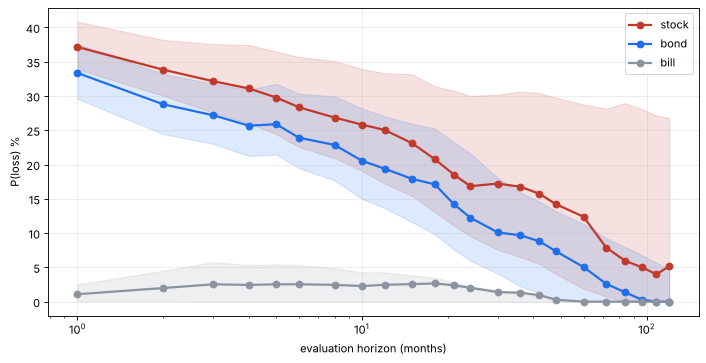

stock                 bond              
     stock     lo     hi   bond     lo     hi
h                                            
1   0.3720 0.3390 0.4080 0.3340 0.2960 0.3760
12  0.2500 0.1720 0.3330 0.1940 0.1370 0.2710
60  0.1240 0.0190 0.2880 0.0500 0.0000 0.1130
120 0.0520 0.0000 0.2680 0.0000 0.0000 0.0470

In [3]:
boot = st.bootstrap_curves(X, H, n_boot=400, seed=1025)
band = st.loss_band(boot)
L = st.loss_probability_curve(X, H)
fig, ax = plt.subplots(figsize=(10.5, 5))
for c in ("stock", "bond", "bill"):
    ax.plot(L.index, L[c] * 100, "o-", color=C[c], lw=2, label=c)
    ax.fill_between(L.index, band[c]["lo"] * 100, band[c]["hi"] * 100, color=C[c], alpha=0.15)
ax.set_xscale("log"); ax.set_xlabel("evaluation horizon (months)")
ax.set_ylabel("P(loss) %"); ax.legend(); plt.show()
out = pd.concat({c: pd.concat([L[c], band[c]], axis=1) for c in ("stock", "bond")}, axis=1)
out.loc[[1, 12, 60, 120]].round(3)

## 4 · CPT value by horizon and the break-even

TK92 value `x^0.88`, `−2.25(−x)^0.88`, with rank-dependent weights (γ = 0.61, δ = 0.69) on the
empirical distribution of overlapping h-month returns. The reference point is a zero nominal
return.

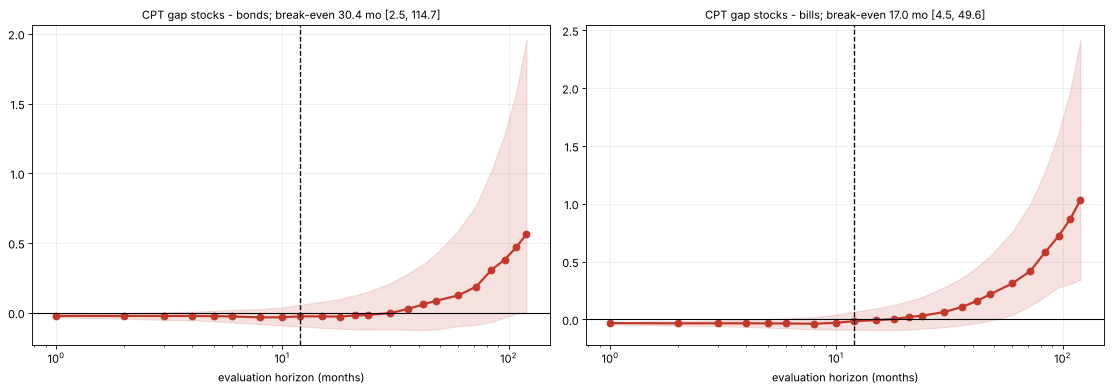

,gap,gap_lo,gap_hi,p,share_stocks_preferred
h,,,,,
1,-0.0228,-0.0341,-0.0122,0.0000,0.0000
3,-0.0228,-0.0510,0.0033,0.0700,0.0350
6,-0.0263,-0.0689,0.0206,0.2750,0.1375
12,-0.0254,-0.0971,0.0572,0.7050,0.3525
24,-0.0159,-0.1209,0.1525,0.8200,0.5900
36,0.0276,-0.1226,0.2824,0.4600,0.7700
60,0.1243,-0.0945,0.5917,0.1650,0.9175
120,0.5642,0.0079,1.9568,0.0450,0.9775


In [4]:
P = st.pt_curve(X, H)
sb = st.summarise_gap(P, boot, "stock", "bond")
sf = st.summarise_gap(P, boot, "stock", "bill")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, s, lbl in ((axes[0], sb, "stocks - bonds"), (axes[1], sf, "stocks - bills")):
    t = s["table"]
    ax.plot(t.index, t["gap"], "o-", color=C["stock"], lw=2)
    ax.fill_between(t.index, t["gap_lo"], t["gap_hi"], color=C["stock"], alpha=0.15)
    ax.axhline(0, color="k", lw=1)
    ax.axvline(12, color="k", ls="--", lw=1.2)
    ax.set_xscale("log"); ax.set_xlabel("evaluation horizon (months)")
    ax.set_title(f"CPT gap {lbl}; break-even {s['break_even']:.1f} mo "
                 f"[{s['be_lo']:.1f}, {s['be_hi']:.1f}]", fontsize=10)
plt.tight_layout(); plt.show()
sb["table"].loc[[1, 3, 6, 12, 24, 36, 60, 120]].round(4)

> 💡 **In plain words.** The shaded band is the range of history-replays. At one month it sits
> wholly below zero (bonds win). At ten years it is just above zero (stocks win). In between,
> where the crossing lives, it straddles zero for years, which is why the crossing can't be
> pinned down.

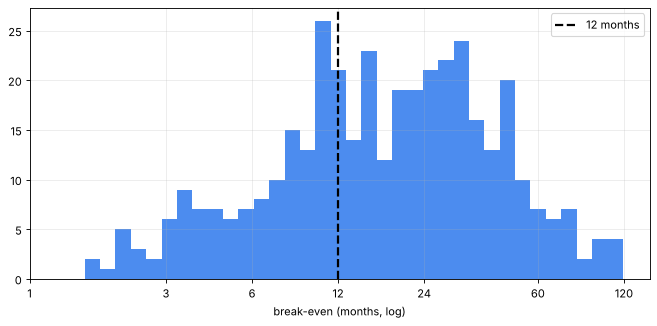

finite in 98% of resamples; in [6, 24] months in 46%
bootstrap median 19.0 months


In [5]:
fin = np.isfinite(sb["be_draws"])
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.hist(np.log10(sb["be_draws"][fin]), bins=35, color="#1f6feb", alpha=0.8)
ax.axvline(np.log10(12), color="k", ls="--", lw=2, label="12 months")
ax.set_xticks(np.log10([1, 3, 6, 12, 24, 60, 120]))
ax.set_xticklabels([1, 3, 6, 12, 24, 60, 120]); ax.set_xlabel("break-even (months, log)")
ax.legend(); plt.show()
print(f"finite in {fin.mean():.0%} of resamples; in [6, 24] months in "
      f"{np.mean((sb['be_draws'] >= 6) & (sb['be_draws'] <= 24)):.0%}")
print(f"bootstrap median {sb['be_median']:.1f} months")

## 5 · Three estimators: why "one year" is the i.i.d. answer

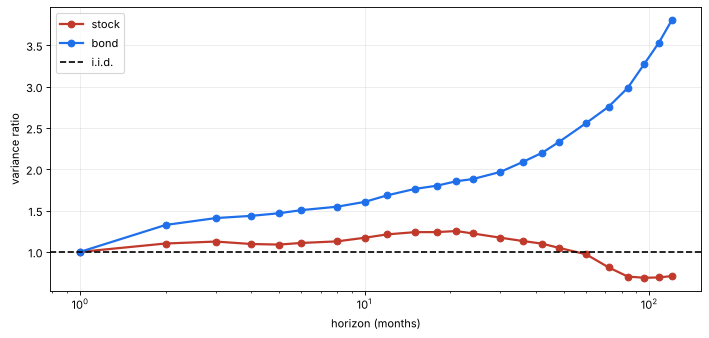

,estimator,window,be_bonds,be_bills
0,overlapping,1926-2018,30.4000,17.0000
1,overlapping,1926-1990 (B&T),22.9000,18.6000
2,nonoverlapping,1926-2018,25.1000,16.2000
3,nonoverlapping,1926-1990 (B&T),18.5000,15.8000
4,iid,1926-2018,11.6000,10.8000
5,iid,1926-1990 (B&T),10.2000,11.6000


In [6]:
rows = []
for meth in ("overlapping", "nonoverlapping", "iid"):
    for lbl, df in (("1926-2018", X), ("1926-1990 (B&T)", X[X.index < "1991-01-01"])):
        Pm = st.pt_curve(df, H, method=meth)
        rows.append({"estimator": meth, "window": lbl,
                     "be_bonds": st.break_even(H, (Pm["stock"] - Pm["bond"]).to_numpy()),
                     "be_bills": st.break_even(H, (Pm["stock"] - Pm["bill"]).to_numpy())})
est = pd.DataFrame(rows)
vr = {}
for c in ("stock", "bond"):
    l1 = np.log1p(X[c].to_numpy()).var()
    vr[c] = [np.log1p(st.horizon_returns(X[c].to_numpy(), k)).var() / (k * l1) for k in H]
fig, ax = plt.subplots(figsize=(10.5, 4.6))
for c in vr:
    ax.plot(H, vr[c], "o-", color=C[c], lw=2, label=c)
ax.axhline(1, color="k", ls="--", lw=1.5, label="i.i.d.")
ax.set_xscale("log"); ax.set_xlabel("horizon (months)"); ax.set_ylabel("variance ratio")
ax.legend(); plt.show()
est.round(1)

> 💡 **In plain words.** Stocks swing *more* over one to two years than independent months
> would imply (runs of bad years), and *less* over ten (mean reversion). Shuffling months
> independently erases both, and the one-to-two-year excess is exactly where the crossing sits.
> That is how an i.i.d. calculation lands near 11.6 months while the real sequence gives 30 months (2.5 years).
> The bond leg's huge ratios are partly a by-product of building it from a monthly-*averaged*
> yield.

## 6 · Robustness: λ, α, weighting, regimes, real terms, maturity

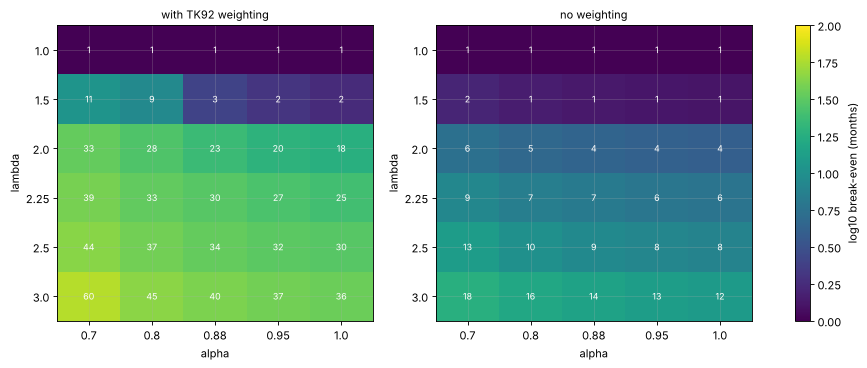

lambda making an ANNUAL evaluator indifferent: 1.79


In [7]:
sw_w = st.param_sweep(X, weighting=True)
sw_n = st.param_sweep(X, weighting=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, sw, ttl in ((axes[0], sw_w, "with TK92 weighting"), (axes[1], sw_n, "no weighting")):
    im = ax.imshow(np.log10(sw.to_numpy()), cmap="viridis", aspect="auto", vmin=0, vmax=2)
    ax.set_xticks(range(sw.shape[1])); ax.set_xticklabels(sw.columns)
    ax.set_yticks(range(sw.shape[0])); ax.set_yticklabels(sw.index)
    ax.set_xlabel("alpha"); ax.set_ylabel("lambda"); ax.set_title(ttl, fontsize=10)
    for i in range(sw.shape[0]):
        for j in range(sw.shape[1]):
            ax.text(j, i, f"{sw.iloc[i, j]:.0f}", ha="center", va="center", color="w",
                    fontsize=8)
plt.colorbar(im, ax=axes, label="log10 break-even (months)"); plt.show()
print(f"lambda making an ANNUAL evaluator indifferent: {st.break_even_lambda(X, 12):.2f}")

In [8]:
R = data.to_real(m)
cases = {"pre-1970": X[X.index < data.SPLIT], "post-1970": X[X.index >= data.SPLIT],
         "1957-2018 nominal": X[X.index >= R.index[0]], "1957-2018 real": R}
rows = []
for k, df in cases.items():
    Pr = st.pt_curve(df, H)
    br = st.bootstrap_curves(df, H, n_boot=200, seed=1026)
    s = st.summarise_gap(Pr, br, "stock", "bond")
    rows.append({"sample": k, "months": len(df), "be": s["break_even"], "lo": s["be_lo"],
                 "hi": s["be_hi"], "finite_share": s["share_finite"]})
mats = []
for mat in (5.0, 10.0, 20.0, 30.0):
    mm = data.load_monthly(maturity=mat)[["stock", "bond", "bill"]]
    Pm = st.pt_curve(mm, H)
    mats.append({"maturity": mat, "bond_vol": mm["bond"].std() * np.sqrt(12),
                 "be": st.break_even(H, (Pm["stock"] - Pm["bond"]).to_numpy())})
display(pd.DataFrame(rows).round(2))
pd.DataFrame(mats).round(3)

,sample,months,be,lo,hi,finite_share
0,pre-1970,522,11.1800,1.6300,inf,0.9500
1,post-1970,587,42.6800,3.2700,inf,0.8000
2,1957-2018 nominal,742,26.4300,3.5200,inf,0.9300
3,1957-2018 real,742,15.7400,3.0700,inf,0.9200


,maturity,bond_vol,be
0,5.0000,0.0260,36.0290
1,10.0000,0.0420,34.2390
2,20.0000,0.0610,30.4090
3,30.0000,0.0710,26.9800


> 💡 **In plain words.** Every knob moves the answer by years. Pre-1970 the crossing sits near a
> year (11 months). Post-1970 it is 43 months. In real terms it is 16 months. Every
> sub-sample's interval runs to "never within ten years". Loss aversion λ does most of the work.
> Without it (λ = 1) stocks win at any horizon.

## 7 · The discipline question: the myopic switcher

Rule (fixed before the run): at each period end, look at the stock market's period return.
After a loss, hold bills next period. After a gain, hold stocks. **One lag**: the period's sign
is known at its last close and sets the position from the next observation. Costs: 5 bp × 1×NAV
one-way per switch. The B&H-minus-switcher net return gap gets a Newey-West t and a paired
circular-block bootstrap (block ≥ 2 × the evaluation period). ΔSharpe is excess-of-bills against
excess-of-bills.

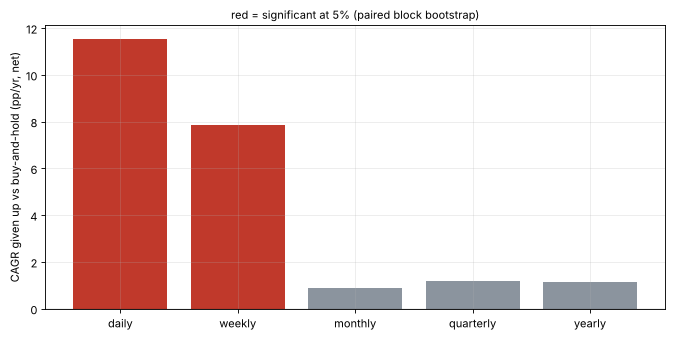

,tape,bh_cagr,my_cagr_gross,my_cagr_net,d_cagr_net,t_hac,p_ret,bh_sharpe,my_sharpe_net,p_sharpe,time_invested,switches_per_year
freq,,,,,,,,,,,,
D,daily S&P price 1990-2018,0.0730,0.0220,-0.0420,0.1150,5.8130,0.0000,0.3360,-0.5470,0.0000,0.5340,129.4410
W,daily S&P price 1990-2018,0.0730,0.0080,-0.0050,0.0780,3.8620,0.0000,0.3360,-0.2290,0.0000,0.5650,27.4930
M,FF total return 1926-2018,0.0990,0.0930,0.0910,0.0090,1.2660,0.1950,0.4290,0.4780,0.5800,0.6280,5.2050
Q,FF total return 1926-2018,0.0990,0.0880,0.0880,0.0120,1.3150,0.1850,0.4290,0.4690,0.7100,0.6830,1.5580
Y,FF total return 1926-2018,0.0990,0.0880,0.0880,0.0110,1.3260,0.1700,0.4290,0.4600,0.9050,0.7620,0.3250


In [9]:
tabs = []
if HAVE_DAILY:
    td = st.discipline_table(d, ["D", "W"], 252, cost_bps=5.0, n_boot=400, base_block=21)
    td["tape"] = "daily S&P price 1990-2018"
    tabs.append(td)
tm = st.discipline_table(X, ["M", "Q", "Y"], 12, cost_bps=5.0, n_boot=400)
tm["tape"] = "FF total return 1926-2018"
tabs.append(tm)
T = pd.concat(tabs)
cols = ["tape", "bh_cagr", "my_cagr_gross", "my_cagr_net", "d_cagr_net", "t_hac", "p_ret",
        "bh_sharpe", "my_sharpe_net", "p_sharpe", "time_invested", "switches_per_year"]
fig, ax = plt.subplots(figsize=(10, 4.6))
colors = ["#c0392b" if p < 0.05 else "#8b949e" for p in T["p_ret"]]
ax.bar([st.FREQ_LABEL[f] for f in T.index], T["d_cagr_net"] * 100, color=colors)
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("CAGR given up vs buy-and-hold (pp/yr, net)")
ax.set_title("red = significant at 5% (paired block bootstrap)", fontsize=10); plt.show()
T[cols].round(3)

In [10]:
if HAVE_DAILY:
    cs = st.cost_sweep(d, "D", 252)
    print("daily checker, cost sweep (S&P price 1990-2018):")
    print(cs.round(4).to_string())
cs_m = st.cost_sweep(X, "M", 12)
print("\nmonthly checker, cost sweep (FF 1926-2018):")
print(cs_m.round(4).to_string())

daily checker, cost sweep (S&P price 1990-2018):
          my_cagr  d_cagr  my_sharpe  bh_sharpe
cost_bps                                       
0.0000     0.0216  0.0514     0.0103     0.3359
2.0000    -0.0045  0.0775    -0.2126     0.3359
5.0000    -0.0424  0.1154    -0.5467     0.3359
10.0000   -0.1024  0.1755    -1.1020     0.3359
25.0000   -0.2611  0.3341    -2.7398     0.3359
50.0000   -0.4660  0.5390    -5.2771     0.3359

monthly checker, cost sweep (FF 1926-2018):
          my_cagr  d_cagr  my_sharpe  bh_sharpe
cost_bps                                       
0.0000     0.0934  0.0060     0.4978     0.4291
2.0000     0.0923  0.0071     0.4898     0.4291
5.0000     0.0906  0.0088     0.4778     0.4291
10.0000    0.0878  0.0117     0.4579     0.4291
25.0000    0.0794  0.0201     0.3979     0.4291
50.0000    0.0654  0.0340     0.2980     0.4291


> 💡 **In plain words.** The daily panicker loses about 11.5% a year (t ≈ 5.8). Part
> of that is costs and part is that daily moves in this period tended to reverse, so they sold
> lows and bought highs. Checking monthly to yearly, the loss is about 1% a year with p
> 0.16-0.21, and the slow switcher's Sharpe is no worse, because it sits out a third of the time
> and gives up premium it wasn't being paid risk for. On the daily tape the price-only S&P
> *understates* the daily cost: buy-and-hold misses dividends while the switcher earns bills.

## 8 · Synthetic control: machinery proof, not market evidence

In [11]:
rows = []
for s_ in (1.0, 0.5, 0.0):
    dfs, tr = data.synthetic_monthly(n_months=6000, signal_strength=s_, seed=1025)
    Ps = st.pt_curve(dfs, H)
    rows.append({"signal_strength": s_,
                 "premium_pa": tr["equity_premium_monthly"] * 12,
                 "be_bonds": st.break_even(H, (Ps["stock"] - Ps["bond"]).to_numpy()),
                 "be_bills": st.break_even(H, (Ps["stock"] - Ps["bill"]).to_numpy())})
fin = []
for seed in range(30):
    dfs, _ = data.synthetic_monthly(n_months=len(X), signal_strength=1.0, seed=seed)
    Ps = st.pt_curve(dfs, H, cols=["stock", "bill"])
    fin.append(st.break_even(H, (Ps["stock"] - Ps["bill"]).to_numpy()))
fin = np.array(fin)
print("planted premium, 92-year samples: break-even vs bills, 10/50/90th pct:",
      np.round(np.percentile(fin[np.isfinite(fin)], [10, 50, 90]), 1))
pd.DataFrame(rows).round(3)

planted premium, 92-year samples: break-even vs bills, 10/50/90th pct: [ 7.2 13.2 27.9]


,signal_strength,premium_pa,be_bonds,be_bills
0,1.0000,0.0660,8.6440,14.5590
1,0.5000,0.0330,61.2850,50.2060
2,0.0000,0.0000,inf,inf


> 💡 **In plain words.** With no premium planted, no horizon makes stocks attractive, as it
> should. With a premium of known size, the method finds a crossing near a year when given 500
> years of data. Given 92 years of the *same* world, it scatters widely. The wide interval on
> the real tape is what this much data can resolve. The method isn't at fault.

## 9 · Going further

- **Treasury bond leg.** A true long-Treasury total-return series is the clean B&T comparison.
  The AAA construction adds a credit spread and averaging smoothness.
- **Portfolio framing.** B&T also solved for the CPT-optimal stock/bond *mix* at each horizon.
  Adding that optimisation is a natural fork, and it inherits the same interval problem.
- **International tapes.** The US equity century is a survivor. A loss-averse investor in a
  market that suffered a long drawdown may never have reached a finite break-even.
- **Other switching rules** (partial de-risking, time-outs, reference points that move with the
  last peak) would cost different amounts. Test them as a family, with a Reality Check, so a
  rule isn't picked for its result.